In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid') 
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('car_price.csv')

print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [3]:
rows, cols = df.shape
print(f'Dataset Shape: {df.shape}')
print(f' - Number of Rows    : {rows:,}')
print(f' - Number of Columns : {cols}')
print(f'\n Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:2}. {col}')

Dataset Shape: (72435, 10)
 - Number of Rows    : 72,435
 - Number of Columns : 10

 Column Names:
    1. model
    2. year
    3. price
    4. transmission
    5. mileage
    6. fuelType
    7. tax
    8. mpg
    9. engineSize
   10. Make


In [4]:
print('Data Types of Each Column:')
print(df.dtypes)
print()

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f' - Numerical Features ({len(numerical_cols)})  : {numerical_cols}')
print(f' - Categorical Features ({len(categorical_cols)}): {categorical_cols}')

Data Types of Each Column:
model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

 - Numerical Features (6)  : ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
 - Categorical Features (4): ['model', 'transmission', 'fuelType', 'Make']


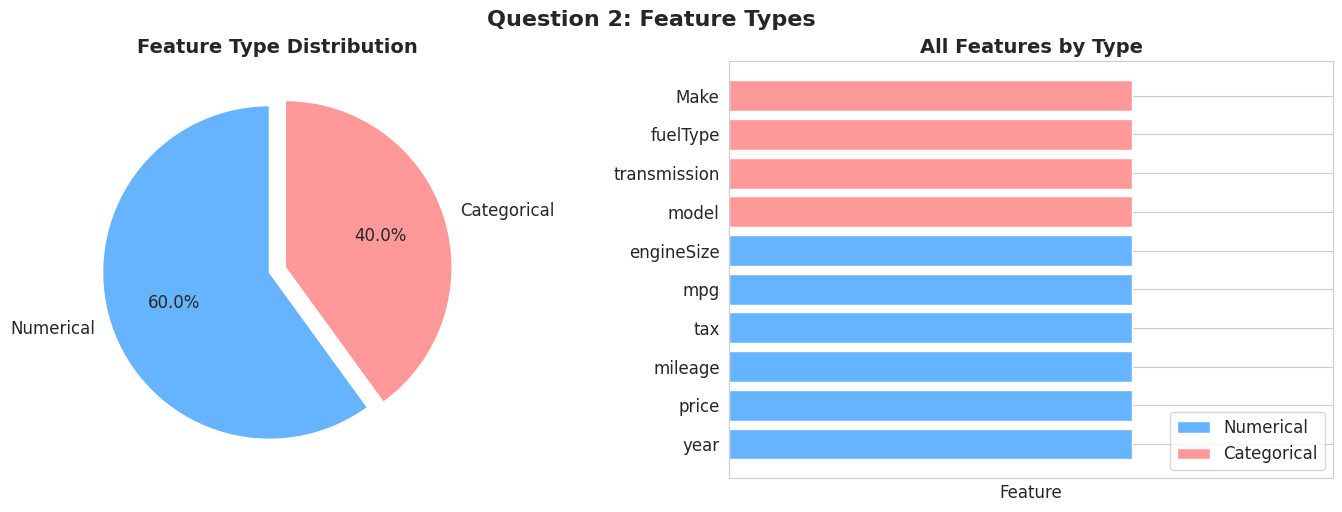

In [5]:
# Visualize feature types
type_counts = {'Numerical': len(numerical_cols), 'Categorical': len(categorical_cols)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(type_counts.values(), labels=type_counts.keys(),
            autopct='%1.1f%%', startangle=90,
            colors=['#66b3ff', '#ff9999'], explode=(0.05, 0.05))
axes[0].set_title('Feature Type Distribution', fontsize=14, fontweight='bold')

# Bar chart with column names
all_cols = [(col, 'Numerical') for col in numerical_cols] + [(col, 'Categorical') for col in categorical_cols]
col_names = [c[0] for c in all_cols]
col_colors = ['#66b3ff' if c[1] == 'Numerical' else '#ff9999' for c in all_cols]
axes[1].barh(col_names, [1]*len(col_names), color=col_colors)
axes[1].set_xlabel('Feature')
axes[1].set_title('All Features by Type', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#66b3ff', label='Numerical'),
                   Patch(facecolor='#ff9999', label='Categorical')]
axes[1].legend(handles=legend_elements, loc='lower right')
axes[1].set_xticks([])

plt.tight_layout()
plt.suptitle('Question 2: Feature Types', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [6]:
print('Statistical Summary of Numerical Features:')
df[numerical_cols].describe().round(2)

Statistical Summary of Numerical Features:


,year,price,mileage,tax,mpg,engineSize
count,68813.00,68814.00,68813.00,68814.00,68814.00,68813.00
mean,2017.08,16583.92,23179.44,116.93,55.84,1.64
std,2.10,9304.41,21347.57,64.08,17.04,0.56
min,1996.00,495.00,1.00,0.00,0.30,0.00
25%,2016.00,10167.25,7199.00,30.00,47.90,1.20
50%,2017.00,14495.00,17521.00,145.00,55.40,1.60
75%,2019.00,20359.75,32478.00,145.00,62.80,2.00
max,2020.00,145000.00,323000.00,580.00,470.80,6.60


In [7]:
print('Unique Values in Categorical Features:')
for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    print(f'\n  [{col}] — {len(unique_vals)} unique values:')
    print(f'{list(unique_vals[:])}')

Unique Values in Categorical Features:

  [model] — 145 unique values:
[' A1', ' A6', ' A4', ' A3', ' Q3', ' Q5', ' A5', ' S4', ' Q2', ' A7', ' TT', ' Q7', ' RS6', ' RS3', ' A8', ' Q8', ' RS4', ' RS5', ' R8', ' SQ5', ' S8', ' SQ7', ' S3', ' S5', ' A2', ' RS7', ' 5 Series', ' 6 Series', ' 7 Series', ' 2 Series', ' 4 Series', ' 1 Series', ' X3', ' 3 Series', ' X5', ' X4', ' i3', ' X1', ' M4', ' X2', ' X6', ' 8 Series', ' Z4', ' X7', ' M5', ' i8', ' M2', ' M3', ' M6', ' Z3', ' Focus', ' Fiesta', ' Puma', ' Kuga', ' EcoSport', ' C-MAX', ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge', ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang', ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka', ' Escort', ' T-Roc', ' Golf', ' Passat', ' T-Cross', ' Polo', ' Tiguan', ' Sharan', ' Up', ' Scirocco', ' Beetle', ' Caddy Maxi Life', ' Caravelle', ' Touareg', ' Arteon', ' Touran', ' Golf SV', ' Amarok', ' Tiguan Allspace', ' Shuttle', ' Jetta', ' CC', ' California

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Values Summary:')
print(missing_df)
print(f'\nTotal missing cells : {df.isnull().sum().sum():,}')
print(f'Columns with missing: {(missing > 0).sum()} out of {len(df.columns)}')

Missing Values Summary:
              Missing Count  Missing %
transmission           3623        5.0
year                   3622        5.0
fuelType               3622        5.0
mileage                3622        5.0
engineSize             3622        5.0
model                  3621        5.0
price                  3621        5.0
tax                    3621        5.0
mpg                    3621        5.0
Make                   3621        5.0

Total missing cells : 36,216
Columns with missing: 10 out of 10


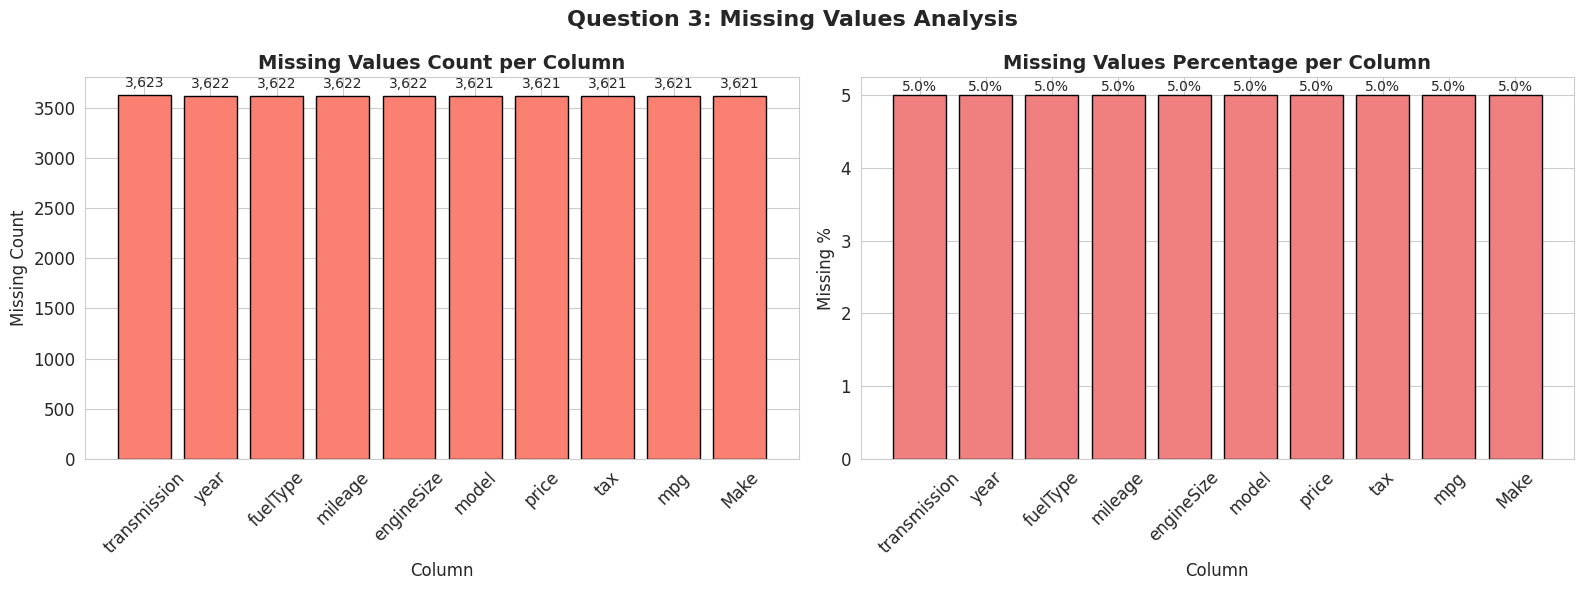

In [9]:
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — missing count
bars = axes[0].bar(cols_with_missing.index, cols_with_missing['Missing Count'],
                    color='salmon', edgecolor='black')
axes[0].set_title('Missing Values Count per Column', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Missing Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, cols_with_missing['Missing Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Bar chart — missing %
bars2 = axes[1].bar(cols_with_missing.index, cols_with_missing['Missing %'],
                     color='lightcoral', edgecolor='black')
axes[1].set_title('Missing Values Percentage per Column', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Missing %')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, cols_with_missing['Missing %']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Question 3: Missing Values Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
price = df['price'].dropna()

print('Price Statistics:')
print(f'   Count  : {price.count():,}')
print(f'   Mean   : £{price.mean():,.2f}')
print(f'   Median : £{price.median():,.2f}')
print(f'   Std Dev: £{price.std():,.2f}')
print(f'   Min    : £{price.min():,.2f}')
print(f'   Max    : £{price.max():,.2f}')
print(f'   Skew   : {price.skew():.3f} (positive = right-skewed)')
print(f'   Kurtosis: {price.kurtosis():.3f}')

Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
outliers = price[(price < Q1 - 1.5*IQR) | (price > Q3 + 1.5*IQR)]
print(f'\n   Q1     : £{Q1:,.2f}')
print(f'   Q3     : £{Q3:,.2f}')
print(f'   IQR    : £{IQR:,.2f}')
print(f'   Outliers: {len(outliers):,} ({len(outliers)/len(price)*100:.1f}%)')

Price Statistics:
   Count  : 68,814
   Mean   : £16,583.92
   Median : £14,495.00
   Std Dev: £9,304.41
   Min    : £495.00
   Max    : £145,000.00
   Skew   : 2.181 (positive = right-skewed)
   Kurtosis: 10.265

   Q1     : £10,167.25
   Q3     : £20,359.75
   IQR    : £10,192.50
   Outliers: 2,573 (3.7%)


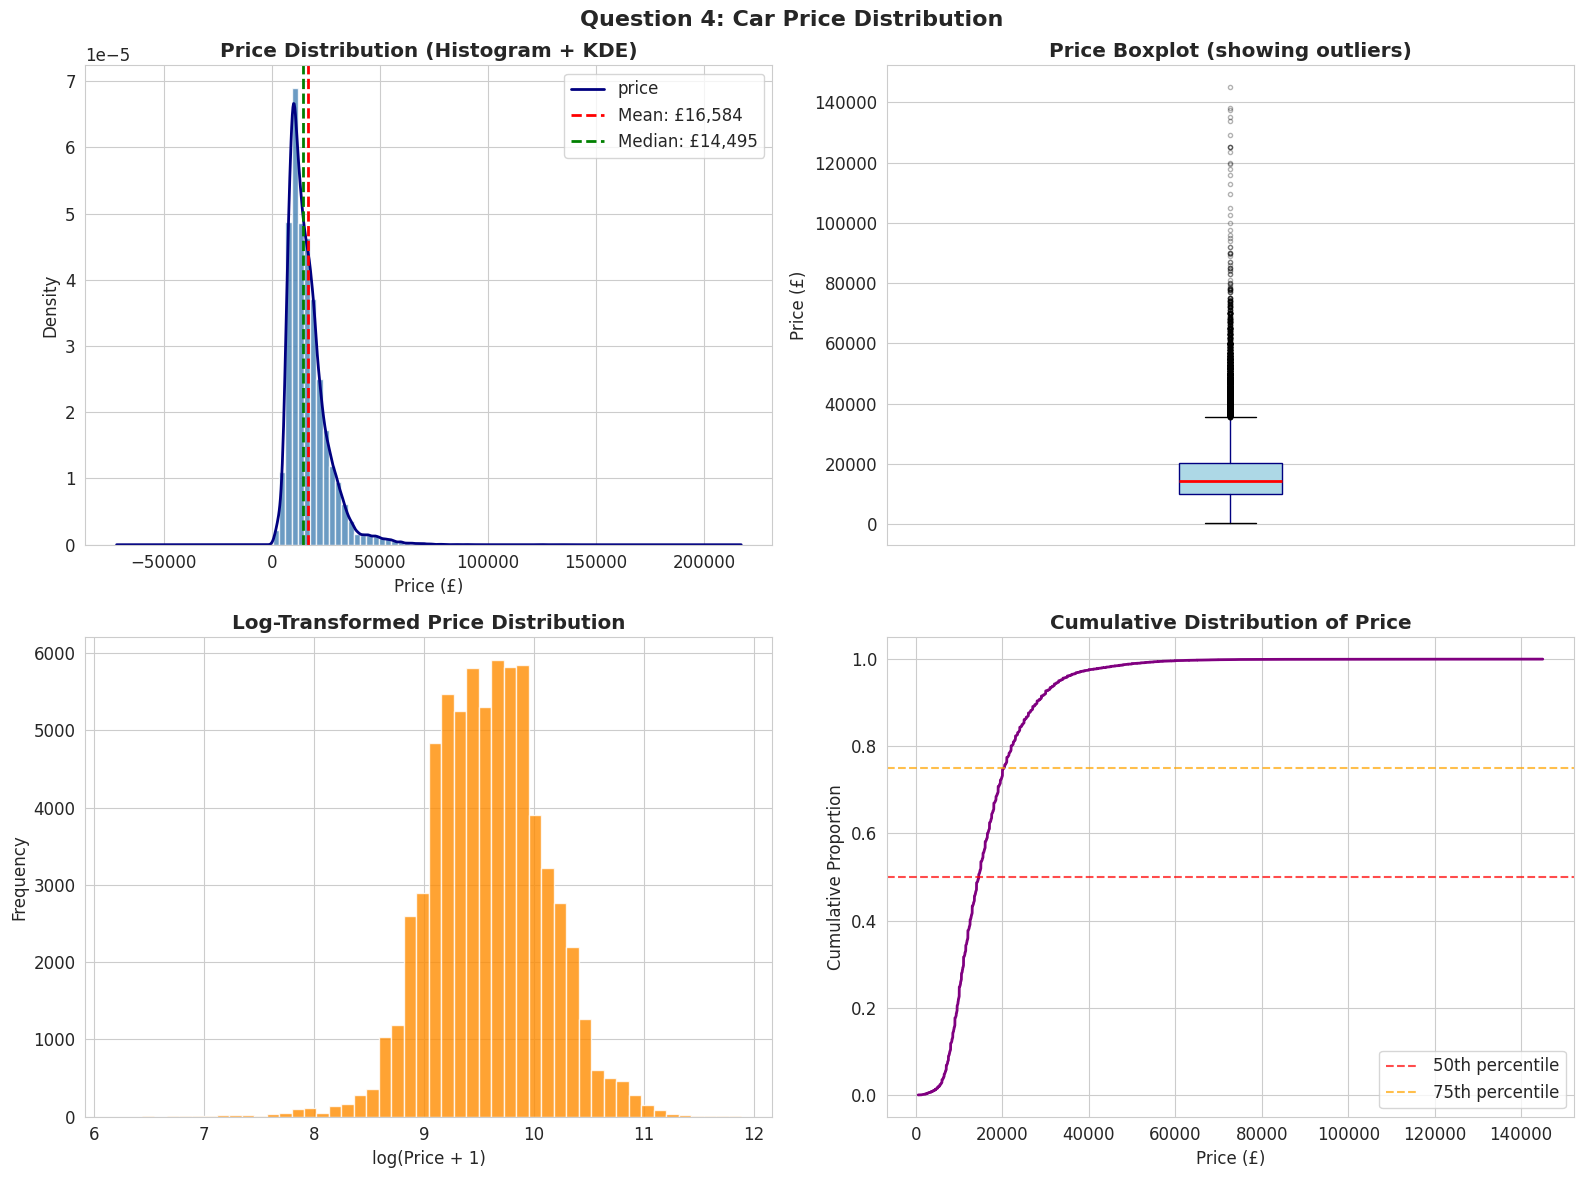

Insight: The price distribution is right-skewed — most cars are priced in the lower range,
            but a few high-priced cars pull the mean above the median.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram with KDE
axes[0, 0].hist(price, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
price.plot.kde(ax=axes[0, 0], color='navy', linewidth=2)
axes[0, 0].axvline(price.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: £{price.mean():,.0f}')
axes[0, 0].axvline(price.median(), color='green', linestyle='--', linewidth=2, label=f'Median: £{price.median():,.0f}')
axes[0, 0].set_title('Price Distribution (Histogram + KDE)', fontweight='bold')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# 2. Boxplot
axes[0, 1].boxplot(price.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   flierprops=dict(marker='o', color='orange', alpha=0.3, markersize=3))
axes[0, 1].set_title('Price Boxplot (showing outliers)', fontweight='bold')
axes[0, 1].set_ylabel('Price (£)')
axes[0, 1].set_xticks([])

# 3. Log-scale Histogram (handles skew better)
axes[1, 0].hist(np.log1p(price), bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Log-Transformed Price Distribution', fontweight='bold')
axes[1, 0].set_xlabel('log(Price + 1)')
axes[1, 0].set_ylabel('Frequency')

# 4. Price by percentile (cumulative)
sorted_price = np.sort(price)
cumulative = np.arange(1, len(sorted_price)+1) / len(sorted_price)
axes[1, 1].plot(sorted_price, cumulative, color='purple', linewidth=2)
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50th percentile')
axes[1, 1].axhline(0.75, color='orange', linestyle='--', alpha=0.7, label='75th percentile')
axes[1, 1].set_title('Cumulative Distribution of Price', fontweight='bold')
axes[1, 1].set_xlabel('Price (£)')
axes[1, 1].set_ylabel('Cumulative Proportion')
axes[1, 1].legend()

plt.suptitle('Question 4: Car Price Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: The price distribution is right-skewed — most cars are priced in the lower range,'
      '\n            but a few high-priced cars pull the mean above the median.')

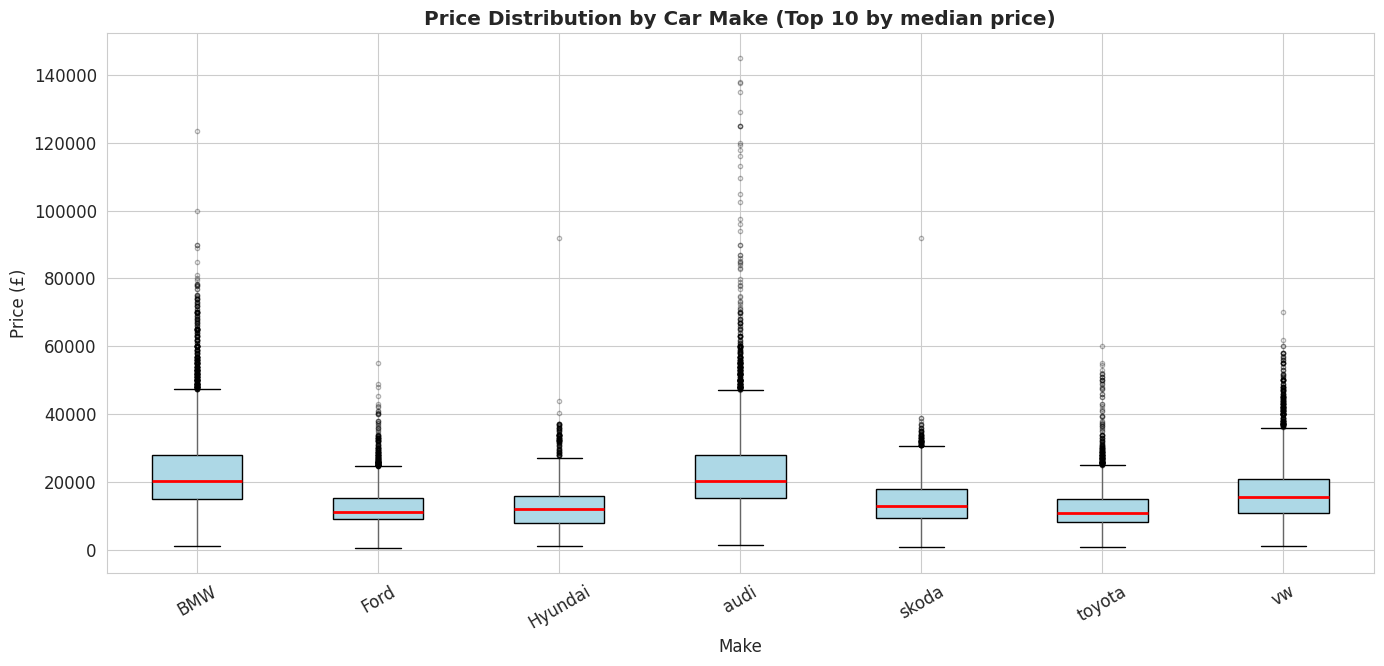

In [12]:
# Price distribution by Make
top_makes = df.groupby('Make')['price'].median().sort_values(ascending=False).head(10).index
df_top = df[df['Make'].isin(top_makes)]

plt.figure(figsize=(14, 7))
df_top.boxplot(column='price', by='Make', ax=plt.gca(),
               patch_artist=True, vert=True, rot=30,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', alpha=0.3, markersize=3))
plt.suptitle('')
plt.title('Price Distribution by Car Make (Top 10 by median price)', fontweight='bold')
plt.xlabel('Make')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

Insight : 

In [13]:
# Correlation of numerical features with price
corr_matrix = df[numerical_cols].corr()
price_corr = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

print('Pearson Correlation with Price (numerical features):')
for col, val in price_corr.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'   {col:<15}: {val:+.4f}  ({direction})')

Pearson Correlation with Price (numerical features):
   engineSize     : +0.6298  (↑ positive)
   year           : +0.5194  (↑ positive)
   mileage        : -0.4275  (↓ negative)
   tax            : +0.3532  (↑ positive)
   mpg            : -0.3356  (↓ negative)


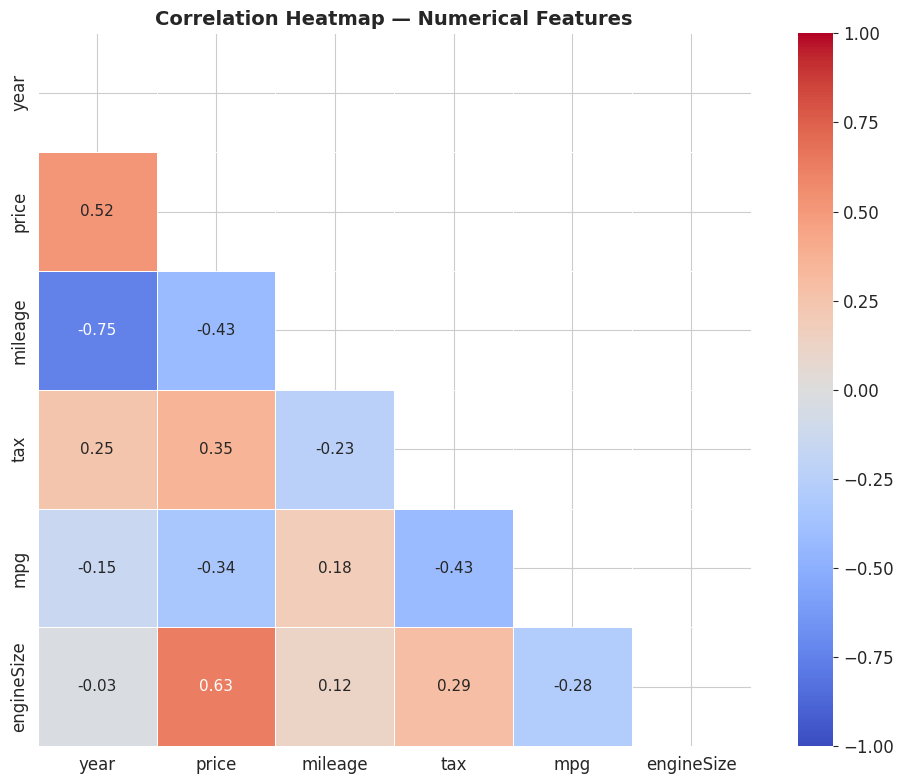

In [14]:
# Full correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

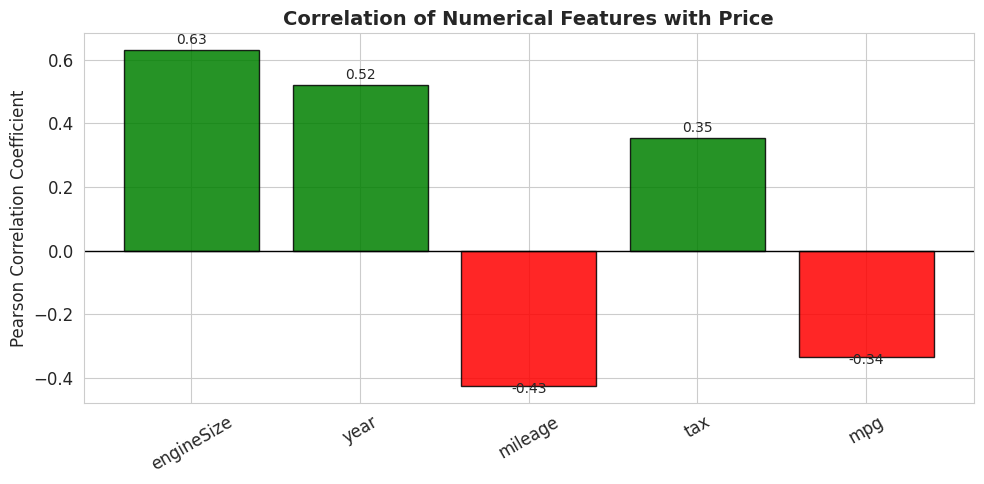

In [15]:
# Bar plot of correlation with price
colors = ['green' if v > 0 else 'red' for v in price_corr.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(price_corr.index, price_corr.values, color=colors, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', linewidth=1)
plt.title('Correlation of Numerical Features with Price', fontsize=14, fontweight='bold')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=30)

for bar, val in zip(bars, price_corr.values):
    ypos = bar.get_height() + 0.01 if val > 0 else bar.get_height() - 0.03
    plt.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

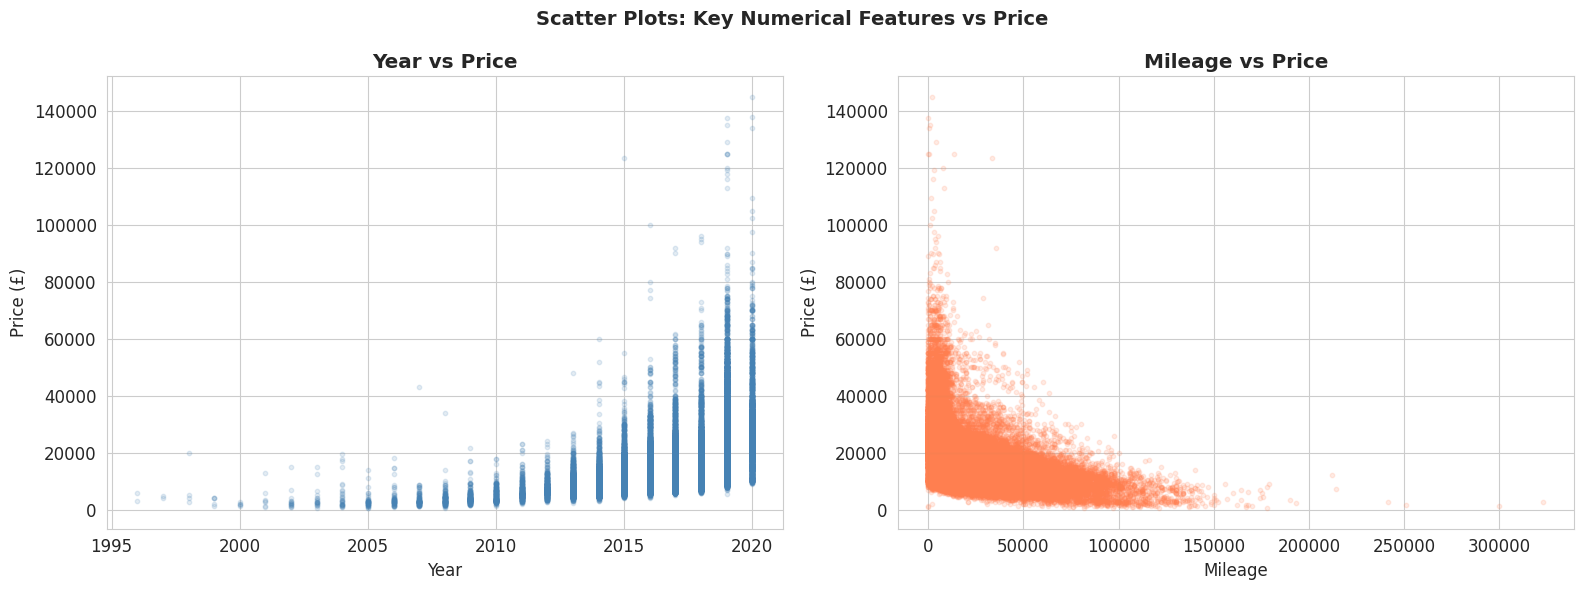

In [16]:
# Scatter: Year vs Price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['year'], df['price'], alpha=0.15, color='steelblue', s=10)
axes[0].set_title('Year vs Price', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price (£)')

axes[1].scatter(df['mileage'], df['price'], alpha=0.15, color='coral', s=10)
axes[1].set_title('Mileage vs Price', fontweight='bold')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price (£)')

plt.suptitle('Scatter Plots: Key Numerical Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

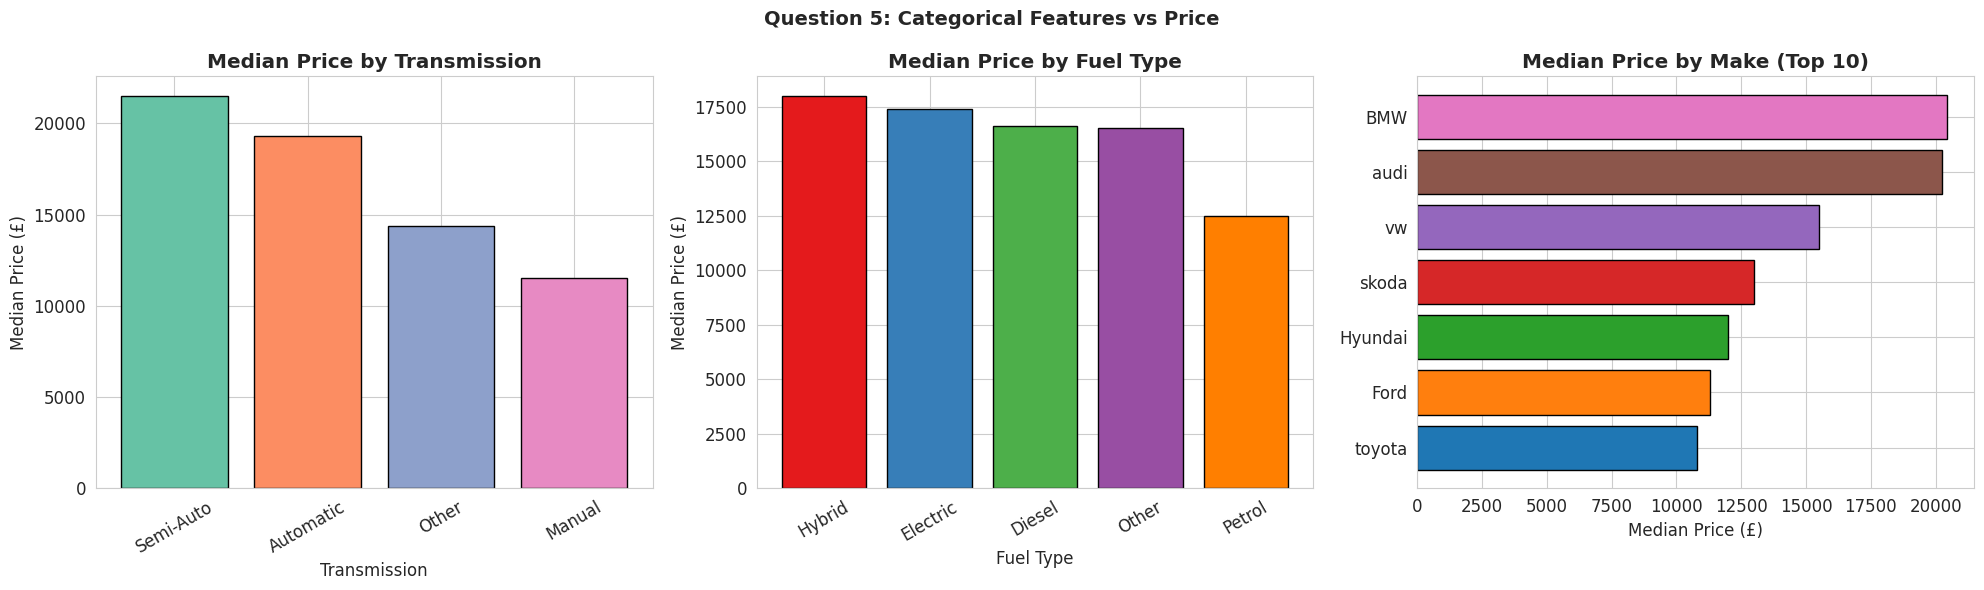

In [17]:
# Categorical features vs price
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Transmission vs Price
trans_price = df.groupby('transmission')['price'].median().sort_values(ascending=False)
axes[0].bar(trans_price.index, trans_price.values, color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Median Price by Transmission', fontweight='bold')
axes[0].set_xlabel('Transmission')
axes[0].set_ylabel('Median Price (£)')
axes[0].tick_params(axis='x', rotation=30)

# Fuel Type vs Price
fuel_price = df.groupby('fuelType')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color=sns.color_palette('Set1'), edgecolor='black')
axes[1].set_title('Median Price by Fuel Type', fontweight='bold')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price (£)')
axes[1].tick_params(axis='x', rotation=30)

# Make vs Price (top 10)
make_price = df.groupby('Make')['price'].median().sort_values(ascending=False).head(10)
axes[2].barh(make_price.index[::-1], make_price.values[::-1],
             color=sns.color_palette('tab10'), edgecolor='black')
axes[2].set_title('Median Price by Make (Top 10)', fontweight='bold')
axes[2].set_xlabel('Median Price (£)')

plt.suptitle('Question 5: Categorical Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

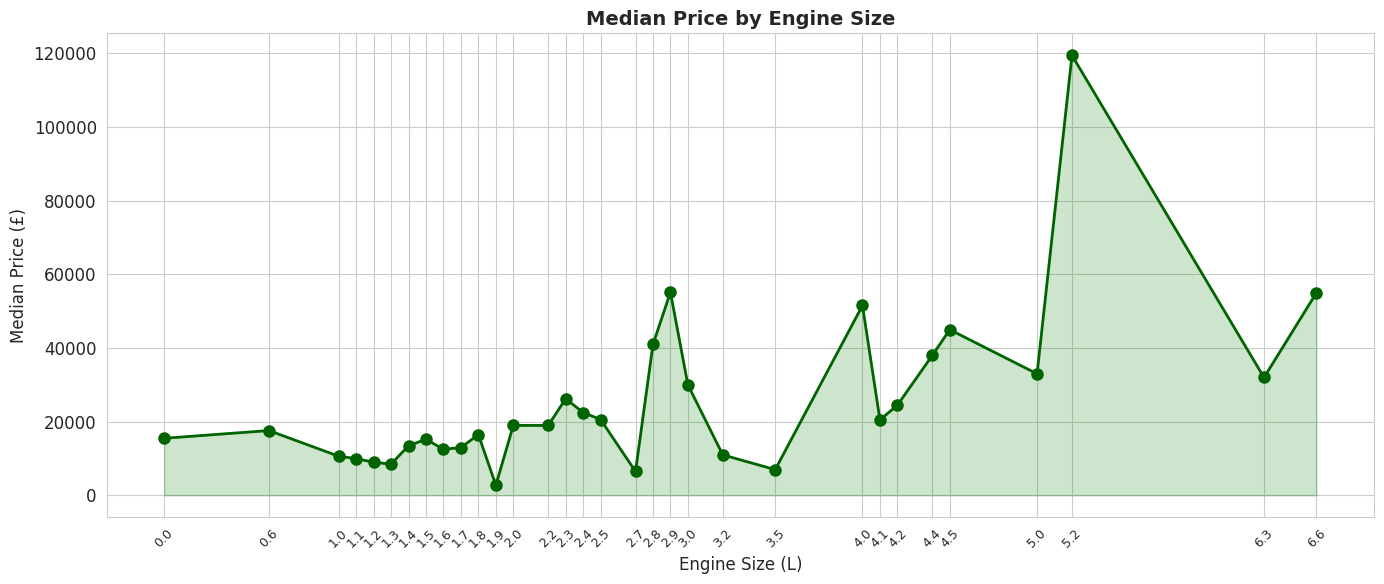

In [18]:
# Engine size vs price
plt.figure(figsize=(14, 6))

engine_price = df.groupby('engineSize')['price'].median().reset_index()
engine_price = engine_price.sort_values('engineSize')

plt.plot(engine_price['engineSize'], engine_price['price'], marker='o', color='darkgreen', linewidth=2, markersize=8)
plt.fill_between(engine_price['engineSize'], engine_price['price'], alpha=0.2, color='green')

plt.title('Median Price by Engine Size', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size (L)')
plt.ylabel('Median Price (£)')

plt.xticks(engine_price['engineSize'], rotation=45, fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
print('=' * 60)
print('         EDA COMPLETE — KEY INSIGHTS SUMMARY')
print('=' * 60)
print(f"""
1. DATASET SIZE
   - {df.shape[0]:,} rows and {df.shape[1]} columns

2. FEATURE TYPES
   - Numerical   : year, price, mileage, tax, mpg, engineSize
   - Categorical : model, transmission, fuelType, Make

3. MISSING VALUES
   - {df.isnull().sum().sum():,} total missing cells across {(df.isnull().sum()>0).sum()} columns
   - Highest: model ({df['model'].isnull().sum():,}), Make ({df['Make'].isnull().sum():,})

4. PRICE DISTRIBUTION
   - Mean   = £{df['price'].mean():,.0f}
   - Median = £{df['price'].median():,.0f}
   - Skew   = {df['price'].skew():.2f} → Right-skewed

5. TOP PREDICTORS OF PRICE
   - Numerical : year (+), mileage (−), engineSize (+)
   - Categorical: Make, transmission, fuelType
""")
print('=' * 60)

         EDA COMPLETE — KEY INSIGHTS SUMMARY

1. DATASET SIZE
   - 72,435 rows and 10 columns

2. FEATURE TYPES
   - Numerical   : year, price, mileage, tax, mpg, engineSize
   - Categorical : model, transmission, fuelType, Make

3. MISSING VALUES
   - 36,216 total missing cells across 10 columns
   - Highest: model (3,621), Make (3,621)

4. PRICE DISTRIBUTION
   - Mean   = £16,584
   - Median = £14,495
   - Skew   = 2.18 → Right-skewed

5. TOP PREDICTORS OF PRICE
   - Numerical : year (+), mileage (−), engineSize (+)
   - Categorical: Make, transmission, fuelType

